<a href="https://colab.research.google.com/github/singprince0311344-boop/Report-on-Corona-Virus-using-python-and-matplotlib/blob/main/Python_corona_project(Kartik_%2CRishav%2CPrince)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
 # 1 Load csv file

df = pd.read_csv("state_level_daily.csv")
print(df.head())

   Unnamed: 0       Date State  Confirmed  Deceased  Recovered  \
0           0  01-Apr-20    AN          0         0          0   
1           1  01-Apr-20    AP         67         0          1   
2           2  01-Apr-20    AR          0         0          0   
3           3  01-Apr-20    AS         15         0          0   
4           4  01-Apr-20    BR          3         0          0   

                    State_Name  
0  Andaman and Nicobar Islands  
1               Andhra Pradesh  
2            Arunachal Pradesh  
3                        Assam  
4                        Bihar  


In [ ]:
# 2. Remove EXtra column
df = df.drop(columns=["Unnamed: 0"], errors='ignore')

print(df.head())

        Date State  Confirmed  Deceased  Recovered  \
0  01-Apr-20    AN          0         0          0   
1  01-Apr-20    AP         67         0          1   
2  01-Apr-20    AR          0         0          0   
3  01-Apr-20    AS         15         0          0   
4  01-Apr-20    BR          3         0          0   

                    State_Name  
0  Andaman and Nicobar Islands  
1               Andhra Pradesh  
2            Arunachal Pradesh  
3                        Assam  
4                        Bihar  


In [ ]:
# 3. Fix Date Format
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

print(df.head())

        Date State  Confirmed  Deceased  Recovered  \
0 2020-04-01    AN          0         0          0   
1 2020-04-01    AP         67         0          1   
2 2020-04-01    AR          0         0          0   
3 2020-04-01    AS         15         0          0   
4 2020-04-01    BR          3         0          0   

                    State_Name  
0  Andaman and Nicobar Islands  
1               Andhra Pradesh  
2            Arunachal Pradesh  
3                        Assam  
4                        Bihar  


In [ ]:
# 4. Check Missing values
print(df.isnull().sum())

Date          0
State         0
Confirmed     0
Deceased      0
Recovered     0
State_Name    0
dtype: int64


In [ ]:
# 5. Fill Missing VAlues
df = df.fillna(0)

In [ ]:
# 6.total cases per state
state_summary = df.groupby("State_Name")[["Confirmed", "Deceased", "Recovered"]].sum()

print(state_summary.sort_values(by="Confirmed", ascending=False).head())

                Confirmed  Deceased  Recovered
State_Name                                    
Total             2020078     41537    1371244
Maharashtra        479779     16791     316375
Tamil Nadu         273969      4456     215056
Andhra Pradesh     196789      1753     112870
Karnataka          158254      2904      80282


In [ ]:
# 7.total cases per day
daily_total = df.groupby("Date")[["Confirmed", "Deceased", "Recovered"]].sum()

print(daily_total.head())

            Confirmed  Deceased  Recovered
Date                                      
2020-03-14        162         4         18
2020-03-15         54         0          8
2020-03-16         30         0          2
2020-03-17         22         2          2
2020-03-18         74         0          0


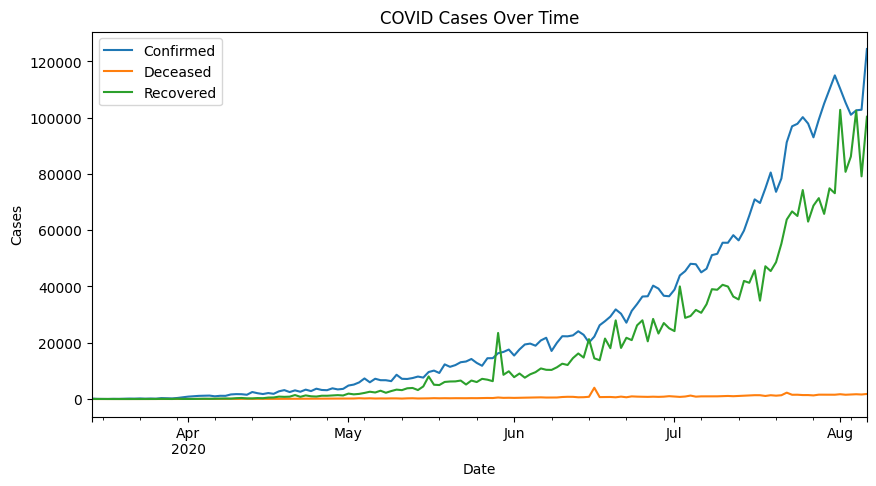

In [ ]:
import matplotlib.pyplot as plt
# 8. Plot GRaph
daily_total.plot(figsize=(10,5))
plt.title("COVID Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

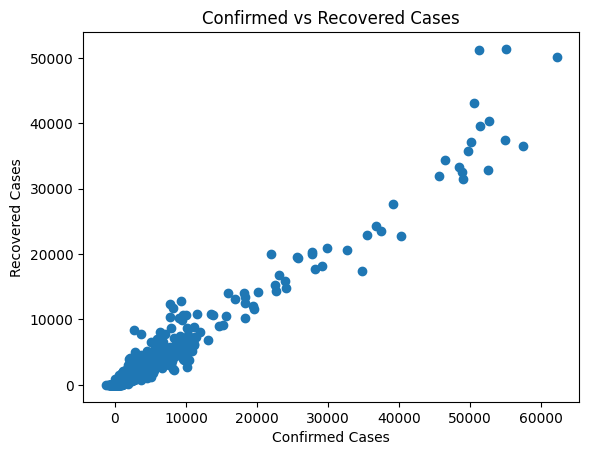

In [ ]:
# 9 . Scatter plot (confirmed vs Recovered)

import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(df["Confirmed"], df["Recovered"])

plt.title("Confirmed vs Recovered Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Recovered Cases")

plt.show()

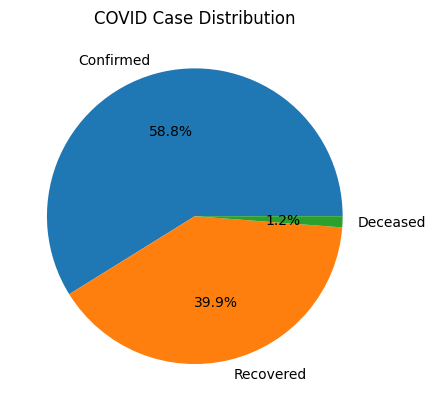

In [ ]:
# 10. Pie Chart (Total cases Distribution)

import matplotlib.pyplot as plt

# Calculate totals
confirmed = df["Confirmed"].sum()
recovered = df["Recovered"].sum()
deceased = df["Deceased"].sum()

# Labels and values
labels = ["Confirmed", "Recovered", "Deceased"]
sizes = [confirmed, recovered, deceased]

# Plot pie chart
plt.pie(sizes, labels=labels, autopct="%1.1f%%")

plt.title("COVID Case Distribution")
plt.show()

In [ ]:
 # 11. Load next data

df = pd.read_csv("district_level_latest.csv")
print(df.head())

   SlNo State_Code                        State                 District_Key  \
0     0         UN             State Unassigned                UN_Unassigned   
1     1         AN  Andaman and Nicobar Islands                  AN_Nicobars   
2     2         AN  Andaman and Nicobar Islands  AN_North and Middle Andaman   
3     3         AN  Andaman and Nicobar Islands             AN_South Andaman   
4     0         AP               Andhra Pradesh          AP_Foreign Evacuees   

                   District  Confirmed  Active  Recovered  Deceased  \
0                Unassigned          0       0          0         0   
1                  Nicobars          0       0          0         0   
2  North and Middle Andaman          1       0          1         0   
3             South Andaman         51      19         32         0   
4          Foreign Evacuees        434       0        434         0   

   Migrated_Other  Delta_Confirmed  Delta_Active  Delta_Recovered  \
0               0      

In [ ]:
# 12.clean data (removed useless column)
df = df.drop(columns=[
    "SlNo", "State_Code", "District_Key",
    "Migrated_Other", "Delta_Confirmed",
    "Delta_Active", "Delta_Recovered",
    "Delta_Deceased", "District_Notes",
    "Last_Updated"
], errors='ignore')

print(df.head())

                         State                  District  Confirmed  Active  \
0             State Unassigned                Unassigned          0       0   
1  Andaman and Nicobar Islands                  Nicobars          0       0   
2  Andaman and Nicobar Islands  North and Middle Andaman          1       0   
3  Andaman and Nicobar Islands             South Andaman         51      19   
4               Andhra Pradesh          Foreign Evacuees        434       0   

   Recovered  Deceased  
0          0         0  
1          0         0  
2          1         0  
3         32         0  
4        434         0  


In [ ]:
# 13. handling missing values
print(df.isnull().sum())

df = df.fillna(0)

State        0
District     0
Confirmed    0
Active       0
Recovered    0
Deceased     0
dtype: int64


In [ ]:
# 14.remove unassigned rose(important)
df = df[df["District"] != "Unassigned"]
df = df[df["State"] != "State Unassigned"]

print(df.head())

                         State                  District  Confirmed  Active  \
1  Andaman and Nicobar Islands                  Nicobars          0       0   
2  Andaman and Nicobar Islands  North and Middle Andaman          1       0   
3  Andaman and Nicobar Islands             South Andaman         51      19   
4               Andhra Pradesh          Foreign Evacuees        434       0   
5               Andhra Pradesh                 Anantapur      21173    6768   

   Recovered  Deceased  
1          0         0  
2          1         0  
3         32         0  
4        434         0  
5      14263       142  


In [ ]:
# 15.basic analyses (state wise total)
state_data = df.groupby("State")[["Confirmed", "Active", "Recovered", "Deceased"]].sum()

print(state_data.sort_values(by="Confirmed", ascending=False).head())

                Confirmed  Active  Recovered  Deceased
State                                                 
Maharashtra        479779  146305     316375     16792
Tamil Nadu         279144   53486     221087      4571
Andhra Pradesh     196789   82166     112870      1753
Karnataka          158254   75067      80281      2897
Delhi              141531   10348     127124      4059


In [ ]:
# 16. top 10 districts
top_districts = df.sort_values(by="Confirmed", ascending=False).head(10)

print(top_districts[["State", "District", "Confirmed"]])

              State         District  Confirmed
772           Delhi          Unknown     140743
346     Maharashtra           Mumbai     120150
609      Tamil Nadu          Chennai     106096
356     Maharashtra             Pune     104353
363     Maharashtra            Thane     100875
285       Karnataka  Bengaluru Urban      67425
573       Telangana        Hyderabad      41449
7    Andhra Pradesh    East Godavari      27580
166         Gujarat        Ahmedabad      27434
751     West Bengal          Kolkata      25882


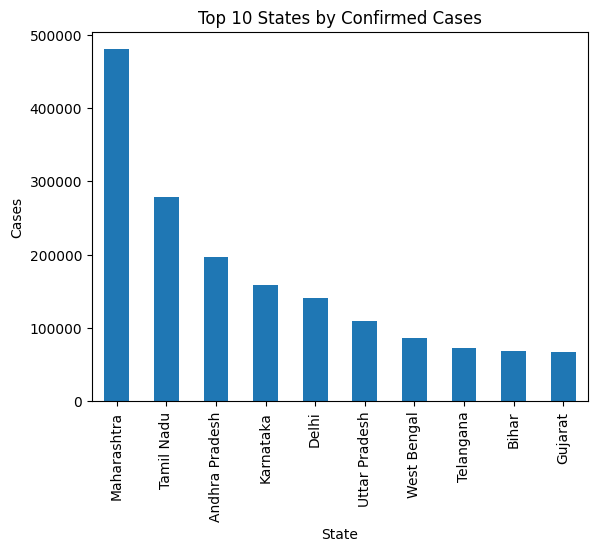

In [ ]:
# 17. Bar Graph(Top States)
import matplotlib.pyplot as plt

state_data.sort_values(by="Confirmed", ascending=False).head(10)["Confirmed"].plot(kind="bar")

plt.title("Top 10 States by Confirmed Cases")
plt.xlabel("State")
plt.ylabel("Cases")

plt.show()

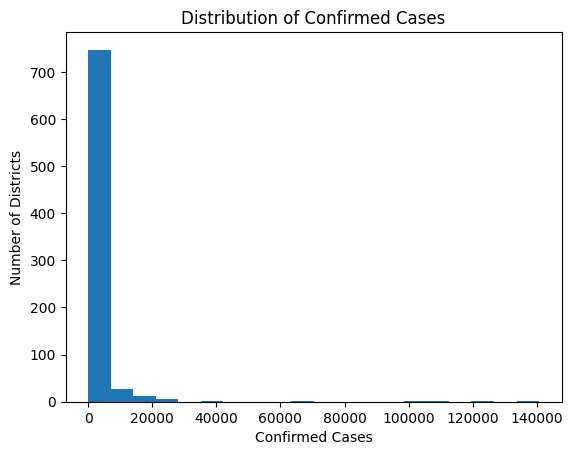

In [ ]:
# 18.Histogram (Confirmed cases)
import matplotlib.pyplot as plt

plt.hist(df["Confirmed"], bins=20)

plt.title("Distribution of Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Number of Districts")

plt.show()

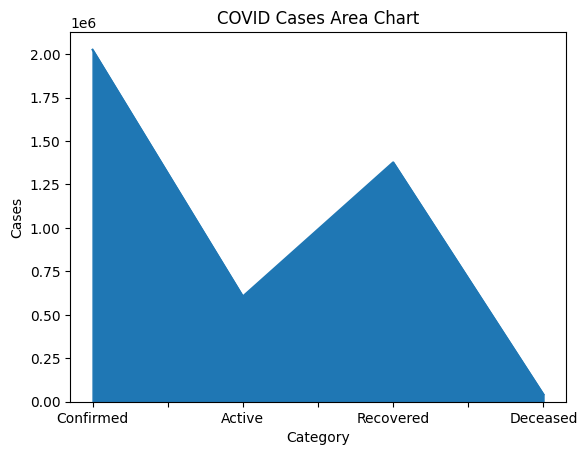

In [ ]:
# 19.Total casses (Area chart)
import matplotlib.pyplot as plt

# Sum of all values
total = df[["Confirmed", "Active", "Recovered", "Deceased"]].sum()

# Area chart
total.plot(kind="area")

plt.title("COVID Cases Area Chart")
plt.xlabel("Category")
plt.ylabel("Cases")

plt.show()

In [ ]:
# 20.load next data
df = pd.read_csv("nation_level_daily.csv")
print(df.head())

           Date  Daily Confirmed  Total Confirmed  Daily Recovered  \
0   30 January                 1                1                0   
1   31 January                 0                1                0   
2  01 February                 0                1                0   
3  02 February                 1                2                0   
4  03 February                 1                3                0   

   Total Recovered  Daily Deceased  Total Deceased  
0                0               0               0  
1                0               0               0  
2                0               0               0  
3                0               0               0  
4                0               0               0  


In [ ]:
# 21.clean column name
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

print(df.columns)

Index(['Date', 'Daily_Confirmed', 'Total_Confirmed', 'Daily_Recovered',
       'Total_Recovered', 'Daily_Deceased', 'Total_Deceased'],
      dtype='str')


In [ ]:
# 22. check missing values
print(df.isnull().sum())

Date               190
Daily_Confirmed      0
Total_Confirmed      0
Daily_Recovered      0
Total_Recovered      0
Daily_Deceased       0
Total_Deceased       0
dtype: int64


In [ ]:
# 23 . Handle Missing Values
# case 1 (Numerical columns)
df = df.ffill()

In [ ]:
# 24 . Ensure Numeric Type
cols = [
    'Daily_Confirmed', 'Total_Confirmed',
    'Daily_Recovered', 'Total_Recovered',
    'Daily_Deceased', 'Total_Deceased'
]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df.head()

,Date,Daily_Confirmed,Total_Confirmed,Daily_Recovered,Total_Recovered,Daily_Deceased,Total_Deceased
0,NaT,1,1,0,0,0,0
1,NaT,0,1,0,0,0,0
2,NaT,0,1,0,0,0,0
3,NaT,1,2,0,0,0,0
4,NaT,1,3,0,0,0,0


In [ ]:
# 25. Remove duplicates
df.drop_duplicates(inplace=True)

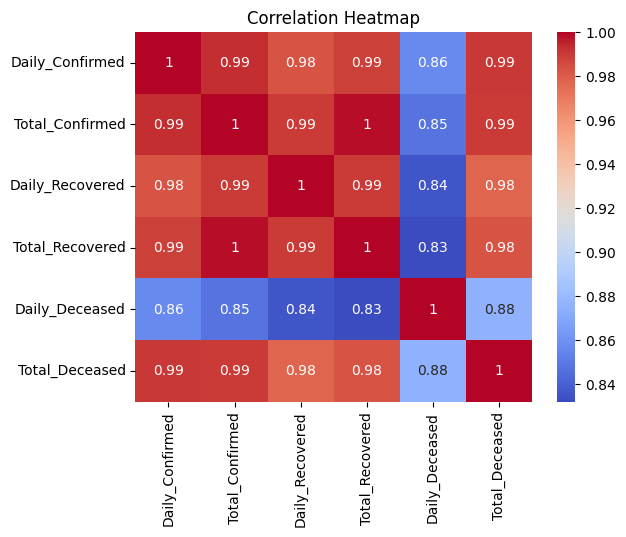

In [ ]:
import seaborn as sns
# 26 . HEATMAP ( CORREALATION)
plt.figure()

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

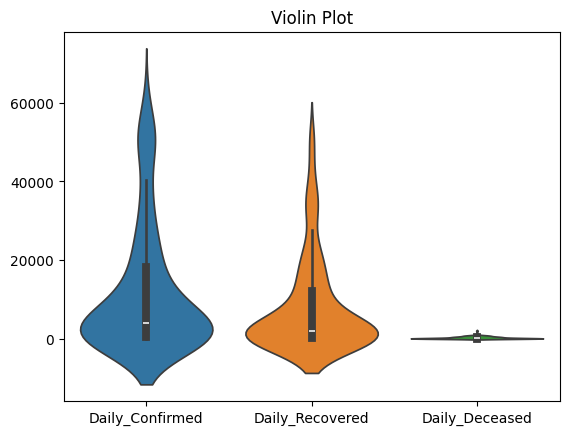

In [ ]:
# 27 VIOLIN PLOT ( CONFIRMED VS RECOVERED VS DECEASED)
import seaborn as sns

plt.figure()
sns.violinplot(data=df[['Daily_Confirmed','Daily_Recovered','Daily_Deceased']])
plt.title("Violin Plot")
plt.show()

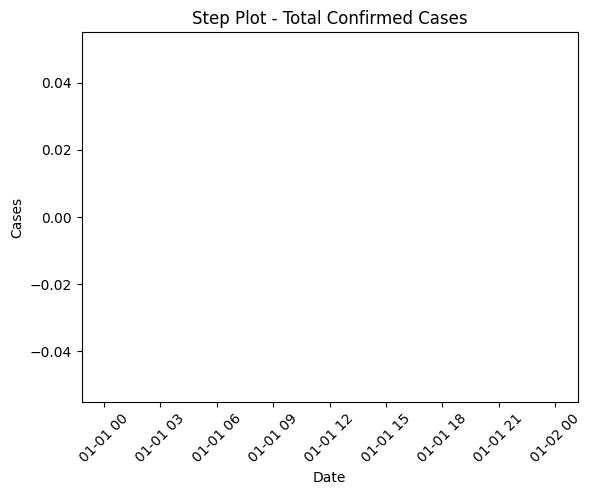

 how total cases increase step-by-step over time (clear jumps).


In [ ]:
# 28 TREND CHANGE CLEARLY ( STEP PLOT)
plt.figure()
plt.step(df['Date'], df['Total_Confirmed'], where='mid')
plt.xticks(rotation=45)

plt.title("Step Plot - Total Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.show()

print(" how total cases increase step-by-step over time (clear jumps).")

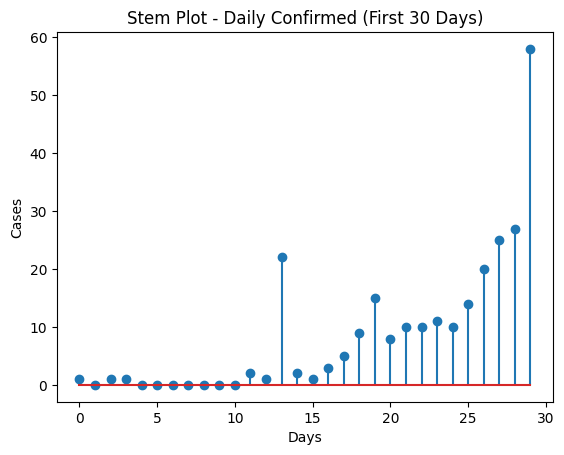

 Shows spikes in daily cases clearly (good for identifying sudden increases).


In [ ]:
 # 29. stem plot (daily spikes)
plt.figure()
plt.stem(df['Daily_Confirmed'].head(30))

plt.title("Stem Plot - Daily Confirmed (First 30 Days)")
plt.xlabel("Days")
plt.ylabel("Cases")

plt.show()

print(" Shows spikes in daily cases clearly (good for identifying sudden increases).")

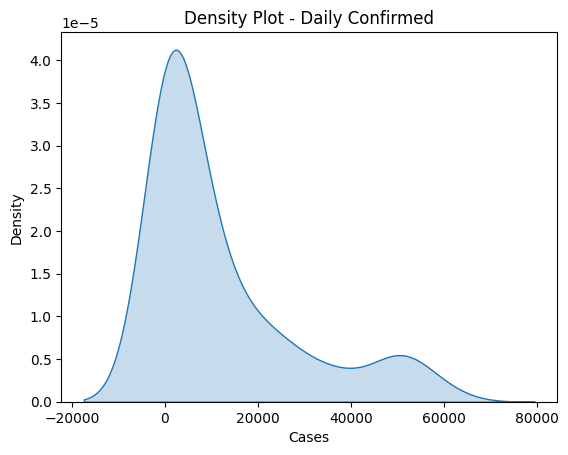

 Shows how frequently certain case values occur (distribution shape).


In [ ]:
# 30. kde plot(data distribution)
import seaborn as sns

plt.figure()
sns.kdeplot(df['Daily_Confirmed'], fill=True)

plt.title("Density Plot - Daily Confirmed")
plt.xlabel("Cases")

plt.show()

print(" Shows how frequently certain case values occur (distribution shape).")

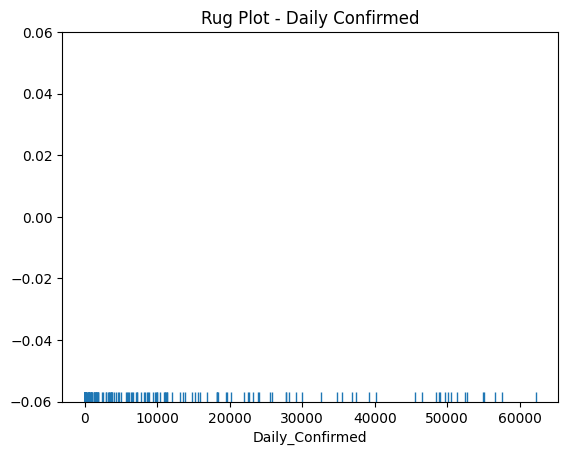

 Shows exact positions of each data point (helps see clustering).


In [ ]:
# 31. Rug plot ( Individual Data Points)
plt.figure()
sns.rugplot(df['Daily_Confirmed'])

plt.title("Rug Plot - Daily Confirmed")

plt.show()

print(" Shows exact positions of each data point (helps see clustering).")

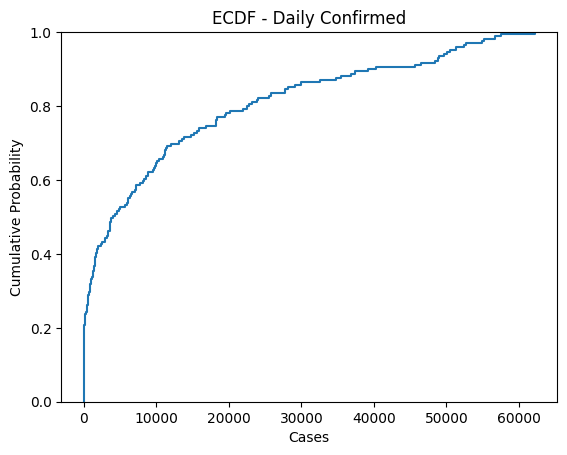

 Shows percentage of days below a certain number of cases.


In [ ]:
# 32. ECDF plot (cumulative%)
plt.figure()
sns.ecdfplot(df['Daily_Confirmed'])

plt.title("ECDF - Daily Confirmed")
plt.xlabel("Cases")
plt.ylabel("Cumulative Probability")

plt.show()

print(" Shows percentage of days below a certain number of cases.")

 Shows relationships between confirmed, recovered, and deaths.


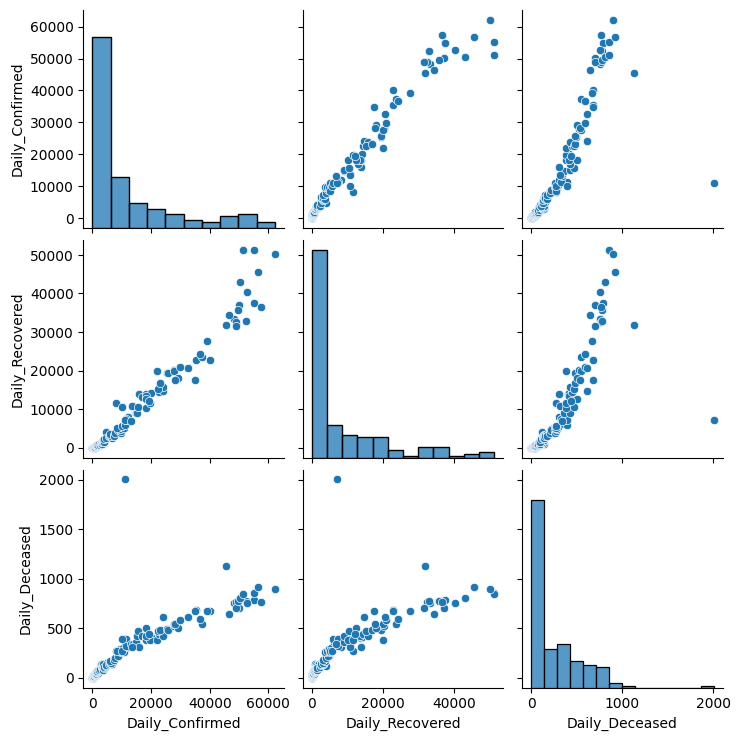

In [ ]:
# 33.pair plot ( Relationships)
sns.pairplot(df[['Daily_Confirmed','Daily_Recovered','Daily_Deceased']])

print(" Shows relationships between confirmed, recovered, and deaths.")

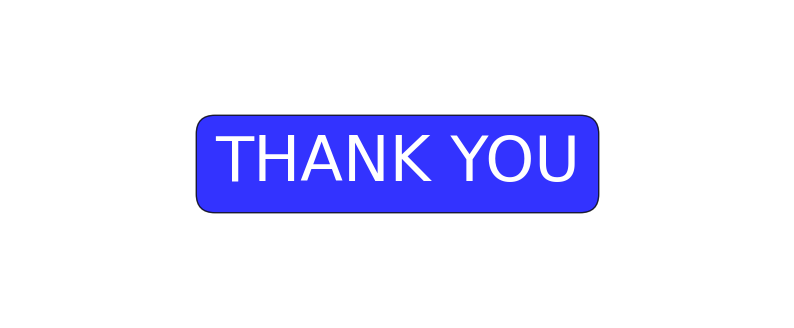

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.text(0.5, 0.5, "THANK YOU",
         fontsize=45,
         ha='center',
         va='center',
         color='white',
         bbox=dict(facecolor='blue', alpha=0.8, boxstyle='round'))

plt.axis('off')
plt.show()